# Signal Processing of Euler Disk

In [26]:
import os

import numpy as np
import euler_disk as ed
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal import (
    welch,
    spectrogram,
    firwin,
    lfilter,
    hilbert,
    butter,
    filtfilt,
    resample_poly,
    windows,
)

## Configuration

In [27]:
t0=26.06 # Change this depending of the actual sample
tmin=t0-2.0
tmax=t0+0.5

## Load your sample

In [30]:
input_dir = "../data/wav/recording_04.wav"  # Change this
output_dir = "../data/output/recording_04/"
os.makedirs(output_dir, exist_ok=True)

fs, x = wavfile.read(input_dir)

if x.ndim > 1:
    x = x[:, 0]

x = np.asarray(x, dtype=np.float32)

N_target = int(3e6)

if len(x) < N_target:
    x = np.pad(x, (0, N_target - len(x)))

x += np.random.randn(len(x)) * 1e-3

N = len(x)
t = np.arange(N) / fs

/tmp/ipykernel_81694/1158398360.py:5: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs, x = wavfile.read(input_dir)


## Step 1: Power Spectral Density
We then select and appropiate band pass for step 3.

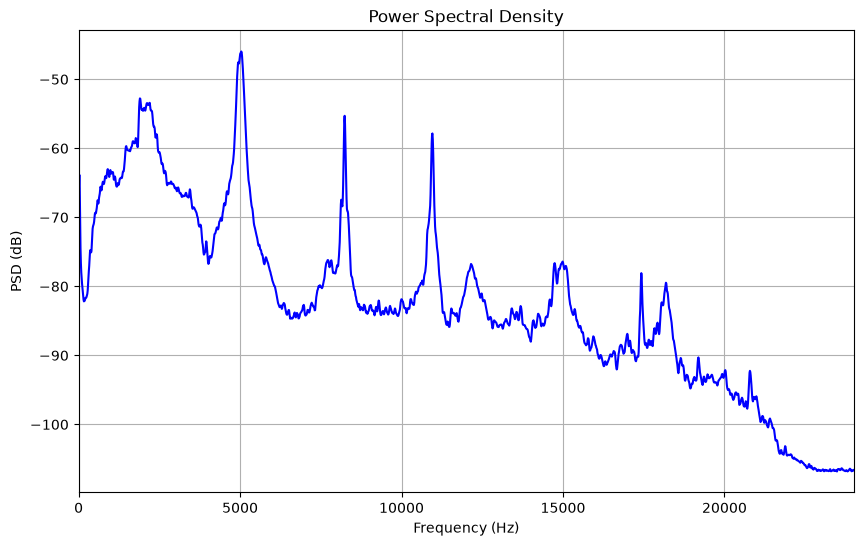

In [38]:
fmax = 24000

frequency, power = welch(
    x,
    fs=fs,
    window="hamming",
    nperseg=4096,
    noverlap=2048,
    nfft=8192,
)

band = (frequency <= fmax)
frequency = frequency[band]
power = power[band]

np.savez_compressed(
    f"{output_dir}/data_welch.npz", frequencies=frequency, power=power
)

fig, ax = plt.subplots(figsize=(10, 6), sharex=True)
ax.plot(frequency, 10 * np.log10(power), color="b", lw=1.5)
ax.set(xlabel="Frequency (Hz)", ylabel="PSD (dB)", xlim=(0, fmax), title="Power Spectral Density")
ax.grid(True)

In [32]:
peaks = ed.peaks(
    input_path=f"{output_dir}/data_welch.npz",
    output_dir=f"{output_dir}",
    prominence=6,   # dB
    distance=2,     # bins (~47 Hz at Δf≈23.4 Hz)
)

data_welch = np.load(f"{output_dir}/data_welch.npz")

n = len(peaks["frequencies"])
print(f"\nFound {n} peaks:\n")
print(f"{'Frequency (Hz)':<18} {'Power (V²/Hz)':<18} {'Prominence (dB)':<18}")
print("-" * 54)

freqs = peaks["frequencies"]
powers = peaks["powers"]
proms = peaks.get("prominences", [None] * n)

for f, p, pr in zip(freqs, powers, proms):
    prom_str = f"{pr:<18.2f}" if pr is not None else f"{'—':<18}"
    print(f"{f:<18.2f} {p:<18.3e} {prom_str}")

peak_data = np.load(f"{output_dir}/peak_data.npz")

welch_db = 10 * np.log10(data_welch["power"] + 1e-20)
peak_db = 10 * np.log10(peak_data["powers"] + 1e-20)


Found 9 peaks:

Frequency (Hz)     Power (V²/Hz)      Prominence (dB)   
------------------------------------------------------
23.44              4.124e-07          8.10              
1898.44            5.282e-06          23.97             
5039.06            2.527e-05          36.20             
8238.28            2.956e-06          29.39             
10957.03           1.642e-06          26.45             
12152.34           2.109e-08          9.11              
14988.28           2.284e-08          11.61             
17425.78           1.553e-08          13.95             
18187.50           1.128e-08          9.44              


## Step 2: Spectogram

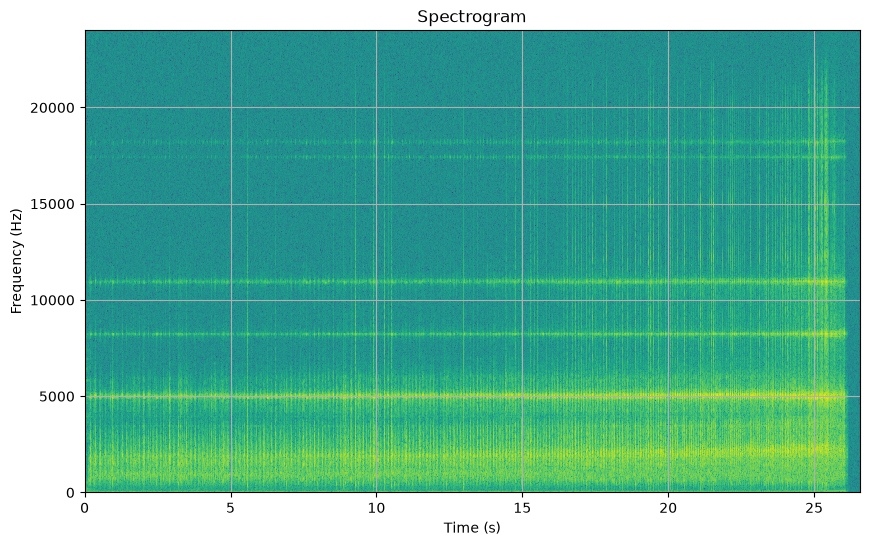

In [39]:
f, ts, S = spectrogram(
    x,
    fs=fs,
    window="hamming",
    nperseg=2048,
    noverlap=1024,
    nfft=4096,
    detrend=False,
    scaling="spectrum",
    mode="complex",
)

fig, ax = plt.subplots(figsize=(10, 6), sharex=True)
ax.pcolormesh(ts, f, 10 * np.log10(np.abs(S) + 1e-12), shading="auto")
ax.set(xlabel="Time (s)", ylabel="Frequency (Hz)", xlim=(0, tmax), ylim=(0, fmax), title="Spectrogram")
ax.grid(True)

## Step 3: Bandpass and Downsample

In [40]:
carrier_peak = peaks["frequencies"][np.argmax(peaks["powers"])]

bandwidth = 500

lower_cutoff = carrier_peak - bandwidth/2
upper_cutoff = carrier_peak + bandwidth/2

In [41]:
B = firwin(
    401,
    [lower_cutoff, upper_cutoff],
    pass_zero=False,
    fs=fs,
)

y = lfilter(B, [1.0], x)  # Filter the signal

a0 = np.abs(hilbert(y))  # Envelope of the filtered signal

In [75]:
a1 = resample_poly(a0, up=1, down=100)

fs_env = fs / 100

bhp, ahp = butter(2, 3 / (fs_env / 2), btype="high")

a2 = lfilter(bhp, ahp, a1)

f_env, ts_env, A0 = spectrogram(
    a2,
    fs=fs_env,
    window="hamming",
    nperseg=512,
    noverlap=500,
    nfft=4096,
    detrend=False,
    scaling="spectrum",
    mode="complex",
)

np.savez_compressed(
    f"{output_dir}/envelope_spectrogram.npz",
    f=f_env,
    t=ts_env,
    A=A0,
)

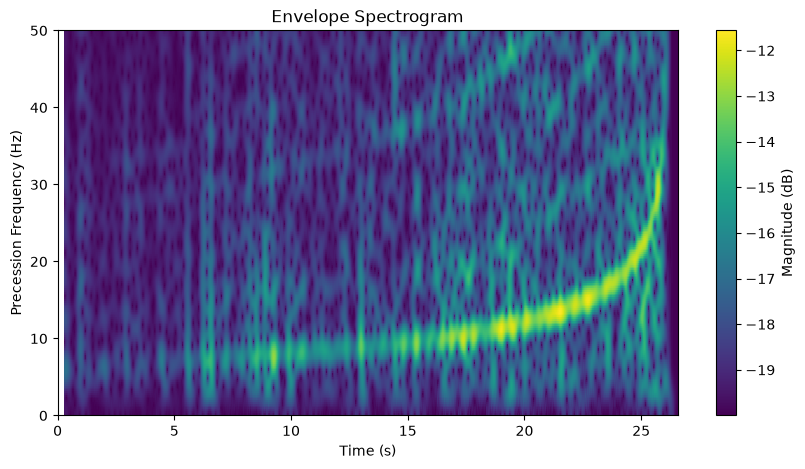

In [77]:
data = np.load(f"{output_dir}/envelope_spectrogram.npz")

f_env = data["f"]
ts_env = data["t"]
A0 = data["A"]

fig, ax = plt.subplots(figsize=(10,5))

spectrogram_db = 10 * np.log10(np.abs(A0) + 0.01)

mesh = ax.pcolormesh(
    ts_env,
    f_env,
    spectrogram_db,
    shading="auto",
    cmap="viridis",

)
ax.set(
    xlabel="Time (s)",
    ylabel="Precession Frequency (Hz)",
    title="Envelope Spectrogram",
    xlim=(0,tmax),
    ylim=(0,50),
)

fig.colorbar(mesh,label="Magnitude (dB)")

## Step 5: Extract Dominant Precession Ridge

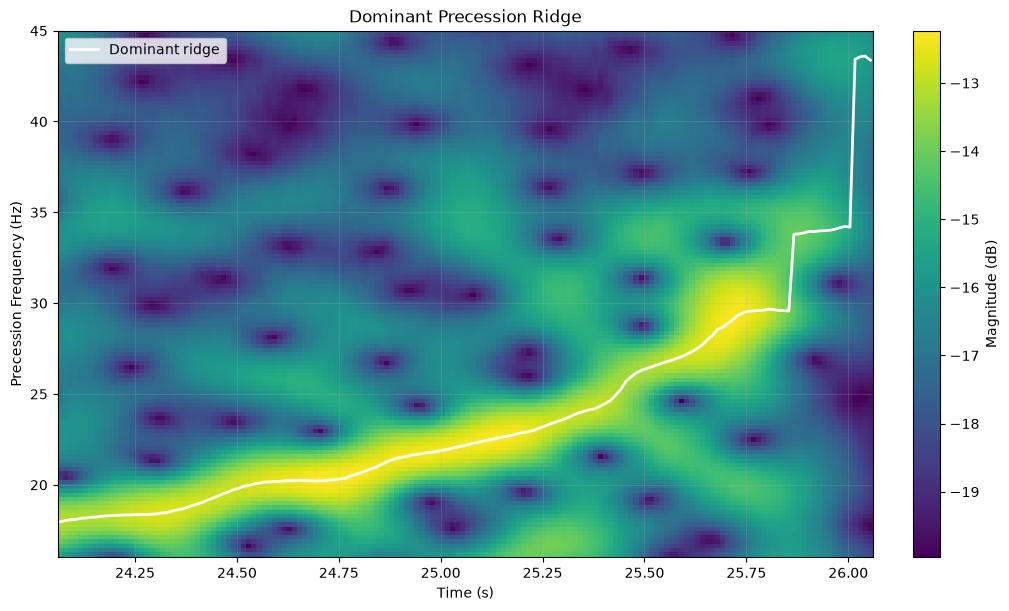

In [78]:
spectrogram_power = np.abs(A0) ** 2

# Frequency of the maximum in each time frame
idx = np.argmax(spectrogram_power, axis=0)

Pm = spectrogram_power[idx, np.arange(len(idx))]

fmax = f_env[idx]
fmax_smooth = fmax.copy()

df = f_env[1] - f_env[0]

# Quadratic interpolation for sub-bin frequency estimation
for k in range(len(idx)):
    i = idx[k]

    if 0 < i < len(f_env) - 1:

        ya = spectrogram_power[i - 1, k] - Pm[k]
        yb = spectrogram_power[i + 1, k] - Pm[k]

        dx = (ya - yb) / (ya + yb) * 0.5

        fmax_smooth[k] += dx * df


# -------------------------------------------------------
# Plot ridge over the envelope spectrogram
# -------------------------------------------------------

time_mask = (ts_env >= tmin) & (ts_env <= t0)
freq_mask = (f_env >= 16) & (f_env <= 45)

fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)

mesh = ax.pcolormesh(
    ts_env[time_mask],
    f_env[freq_mask],
    spectrogram_db[np.ix_(freq_mask, time_mask)],
    shading="auto",
    cmap="viridis",
)

ax.plot(
    ts_env[time_mask],
    fmax_smooth[time_mask],
    color="white",
    linewidth=2,
    label="Dominant ridge",
)

ax.set(
    xlabel="Time (s)",
    ylabel="Precession Frequency (Hz)",
    title="Dominant Precession Ridge",
    xlim=(tmin, t0),
    ylim=(16, 45),
)

ax.grid(True, which="both", alpha=0.2)
ax.legend(loc="upper left")

cbar = fig.colorbar(mesh, ax=ax)
cbar.set_label("Magnitude (dB)")

plt.show()

## Step 6: Power Fit

alpha = 0.33457837027112275
k = 21.31840376304955


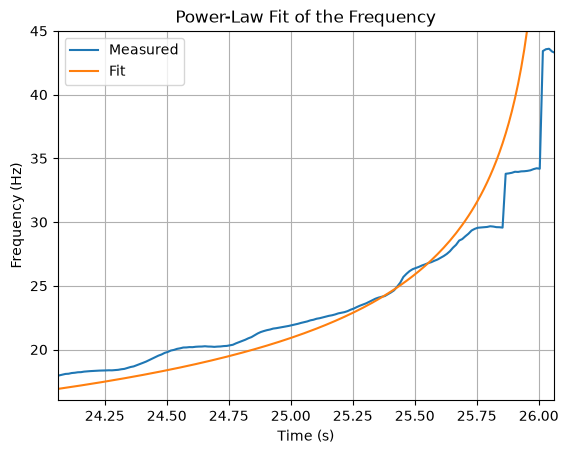

In [ ]:
fit_window = 2.0      # seconds before t0 used for fitting

fit_start = t0 - fit_window

fit_mask = (ts_env >= fit_start) & (ts_env < t0)

xfit = np.log10(t0 - ts_env[fit_mask])
yfit = np.log10(fmax_smooth[fit_mask])

slope, intercept = np.polyfit(xfit, yfit, 1)
alpha = -slope
k = 10**intercept

print("alpha =", alpha)
print("k =", k)

f_model = np.zeros_like(ts_env)

f_model[fit_mask] = k * (1 / (t0 - ts_env[fit_mask])) ** alpha

if np.any(~fit_mask):
    f_model[~fit_mask] = f_model[np.where(fit_mask)[0][-1]]

plt.figure()
plt.plot(ts_env, fmax_smooth, label="Measured")
plt.plot(ts_env, f_model, label="Fit")
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.xlim(tmin, t0)
plt.ylim(16, 45)
plt.title("Power-Law Fit of the Frequency")
plt.legend()
plt.grid(True)

## Step 7: Phase Demodulation

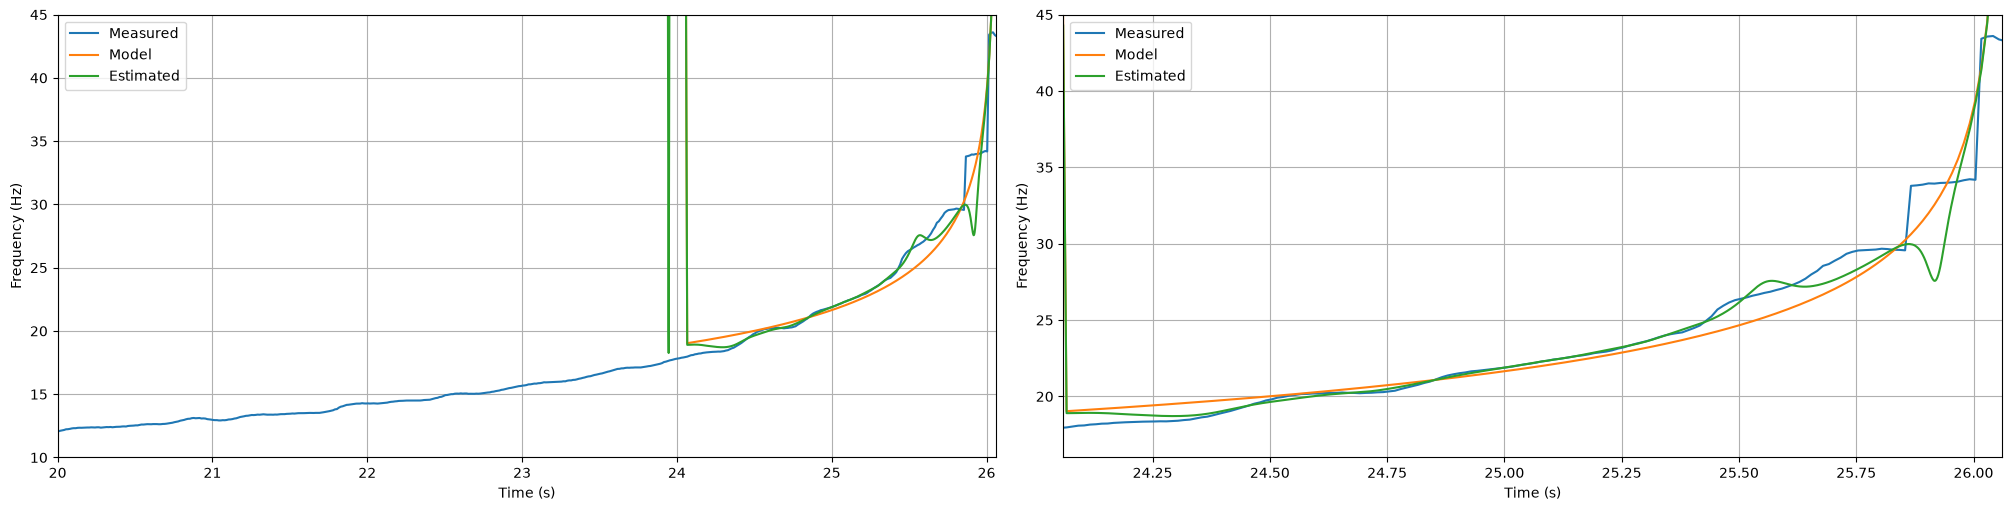

In [100]:
t2 = np.arange(len(a2)) / fs_env

f0 = np.interp(t2, ts_env, f_model)

w0 = 2 * np.pi * f0

phi = np.cumsum(w0) / fs_env

exp_comp = np.exp(-1j * phi)

a2_bb = a2 * exp_comp

blp, alp = butter(2, 1.5 / (fs_env / 2))

a2_f = filtfilt(blp, alp, a2_bb)

phi_i = np.unwrap(np.angle(a2_f))

dw = np.concatenate([np.diff(phi_i) * fs_env, [0]])

f_est = (w0 + dw) / (2 * np.pi)

fig, ax = plt.subplots(1,2,figsize=(20, 5), constrained_layout=True)
ax[0].plot(ts_env, fmax_smooth, label="Measured")
ax[0].plot(ts_env, f_model, label="Model")
ax[0].plot(t2, f_est, label="Estimated")
ax[0].set(xlabel="Time (s)", ylabel="Frequency (Hz)", xlim=(20.0, t0), ylim=(10, 45))
ax[0].legend()
ax[0].grid(True)

ax[1].plot(ts_env, fmax_smooth, label="Measured")
ax[1].plot(ts_env, f_model, label="Model")
ax[1].plot(t2, f_est, label="Estimated")
ax[1].set(xlabel="Time (s)", ylabel="Frequency (Hz)", xlim=(tmin, t0), ylim=(16, 45))
ax[1].legend()
ax[1].grid(True)

plt.grid(True)


plt.show()